In [1]:
# ── Cell 0.1: Imports ─────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')   # suppresses minor pandas/matplotlib formatting warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [2]:
# ── Cell 0.2: Style & Paths ───────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Detect where Jupyter's working directory is and set paths accordingly.
# When you launch Jupyter from the project root and open a notebook in notebooks/,
# the working directory (os.getcwd()) becomes the notebooks/ folder.
# outputs/figures/ lives at the project root, one level up — hence the "../"
cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    FIGURES_PATH = os.path.join("..", "outputs", "figures")
    ENV_PATH     = "../.env"
else:
    # In case Jupyter left CWD at project root
    FIGURES_PATH = os.path.join("outputs", "figures")
    ENV_PATH     = ".env"

os.makedirs(FIGURES_PATH, exist_ok=True)

print(f"✓ Working directory:  {cwd}")
print(f"✓ Figures will save to: {os.path.abspath(FIGURES_PATH)}")

✓ Working directory:  C:\Users\jabez\Documents\ai-job-displacement-observatory\notebooks
✓ Figures will save to: C:\Users\jabez\Documents\ai-job-displacement-observatory\outputs\figures


In [3]:
# ── Cell 0.3: Database Connection ────────────────────────────────────────────
load_dotenv(ENV_PATH)

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# Confirm connection and verify Part 3 loaded correctly
print("=== DATABASE ROW COUNTS ===")
with engine.connect() as conn:
    for table in ['bls_oews', 'automation_scores', 'onet_work_activities', 'onet_occupations']:
        count = conn.execute(text(f"SELECT COUNT(*) FROM {table}")).scalar()
        print(f"  {table:<30} {count:>12,} rows")

print("\n✓ Database connection confirmed. Ready for analysis.")

=== DATABASE ROW COUNTS ===
  bls_oews                          1,182,597 rows
  automation_scores                       702 rows
  onet_work_activities                 73,308 rows
  onet_occupations                      1,016 rows

✓ Database connection confirmed. Ready for analysis.


In [4]:
# ── DIAGNOSTIC: What are the actual occ_group values? ────────────────────────
diag = pd.read_sql("""
    SELECT occ_group, COUNT(*) AS cnt
    FROM bls_oews
    WHERE year = 2025 AND data_type = 'national'
    GROUP BY occ_group
    ORDER BY cnt DESC
""", engine)

print(diag.to_string(index=False))

occ_group  cnt
     None 1401


In [5]:
# ── Cell 0.4: SQL Filter Constants (replaces occ_group column) ───────────────
# The occ_group column is NULL in our database due to a column name mismatch
# during ingestion. We derive group level directly from the SOC code pattern —
# this is actually more reliable since it doesn't depend on any column value.

MAJOR_FILTER    = "RIGHT(occ_code, 4) = '0000' AND occ_code != '00-0000'"
DETAILED_FILTER = "RIGHT(occ_code, 1) != '0'"

print("✓ SQL filter constants defined.")
print(f"  MAJOR_FILTER    = {MAJOR_FILTER}")
print(f"  DETAILED_FILTER = {DETAILED_FILTER}")

✓ SQL filter constants defined.
  MAJOR_FILTER    = RIGHT(occ_code, 4) = '0000' AND occ_code != '00-0000'
  DETAILED_FILTER = RIGHT(occ_code, 1) != '0'


## Section 1 — BLS Employment Data EDA

Exploring Bureau of Labor Statistics OEWS data.
Coverage: 2018–2025, national + MSA level.
Focus: employment distribution, wage patterns, data quality, COVID distortion.

In [6]:
# ── Cell 1.1: National Employment by Major Occupation Group (2025) ────────────
query_major = f"""
    SELECT occ_code, occ_title, tot_emp
    FROM bls_oews
    WHERE year      = 2025
      AND data_type = 'national'
      AND {MAJOR_FILTER}
      AND tot_emp IS NOT NULL
"""
df_major_2025 = pd.read_sql(query_major, engine)
df_major_2025['tot_emp'] = pd.to_numeric(df_major_2025['tot_emp'], errors='coerce')
df_major_2025 = df_major_2025.dropna(subset=['tot_emp'])

df_major_2025['short_title'] = (
    df_major_2025['occ_title']
    .str.replace(' Occupations', '', regex=False)
    .str.strip()
)
print(f"Major occupation groups loaded: {len(df_major_2025)}")
print(df_major_2025[['short_title', 'tot_emp']].head(5).to_string(index=False))

Major occupation groups loaded: 22
                       short_title  tot_emp
                        Management 11132700
 Business and Financial Operations 10537240
         Computer and Mathematical  5260110
      Architecture and Engineering  2617130
Life, Physical, and Social Science  1473260


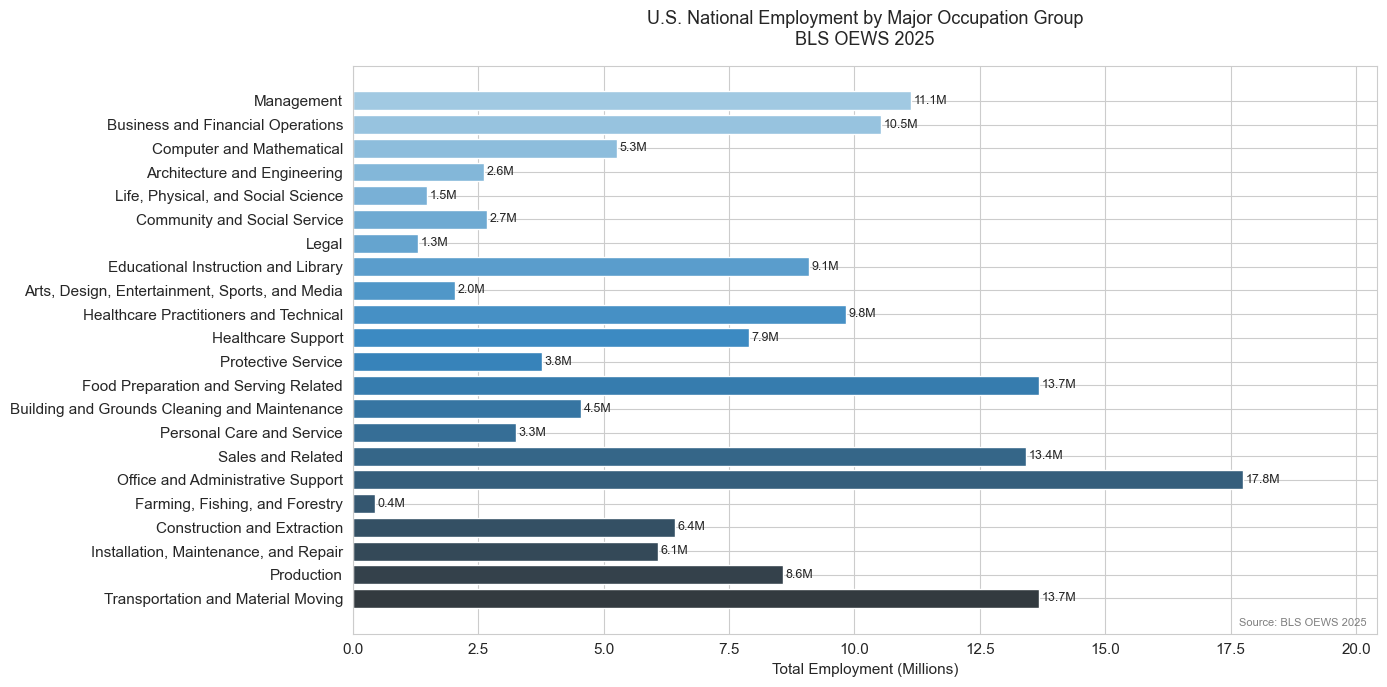

✓ Saved: 01_major_group_employment_2025.png


In [7]:
# ── Cell 1.2: Chart — Major Group Employment Bar Chart ───────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    y     = df_major_2025['short_title'],
    width = df_major_2025['tot_emp'] / 1_000_000,
    color = sns.color_palette("Blues_d", len(df_major_2025))
)
ax.invert_yaxis()   # largest bar at top

for bar, val in zip(bars, df_major_2025['tot_emp']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{val/1e6:.1f}M", va='center', fontsize=9)

ax.set_xlim(0, df_major_2025['tot_emp'].max() / 1e6 * 1.15)
ax.set_xlabel("Total Employment (Millions)")
ax.set_title("U.S. National Employment by Major Occupation Group\nBLS OEWS 2025", pad=15)
ax.text(0.99, 0.01, "Source: BLS OEWS 2025",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/01_major_group_employment_2025.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 01_major_group_employment_2025.png")

In [8]:
# ── Cell 1.3: Load YoY Trend Data ───────────────────────────────────────────
query_trend = f"""
    SELECT year, occ_title, tot_emp
    FROM bls_oews
    WHERE data_type = 'national'
      AND {MAJOR_FILTER}
      AND tot_emp IS NOT NULL
    ORDER BY year, occ_title
"""
df_trend = pd.read_sql(query_trend, engine)
df_trend['tot_emp'] = pd.to_numeric(df_trend['tot_emp'], errors='coerce')
df_trend = df_trend.dropna(subset=['tot_emp'])

df_trend['short_title'] = (
    df_trend['occ_title']
    .str.replace(' Occupations', '', regex=False)
    .str.strip()
)

top_7_groups = (
    df_trend[df_trend['year'] == 2025]
    .nlargest(7, 'tot_emp')['short_title']
    .tolist()
)
df_trend_filtered = df_trend[df_trend['short_title'].isin(top_7_groups)]

print("Tracking trends for:")
for g in top_7_groups:
    print(f"  - {g}")

Tracking trends for:
  - Office and Administrative Support
  - Food Preparation and Serving Related
  - Transportation and Material Moving
  - Sales and Related
  - Management
  - Business and Financial Operations
  - Healthcare Practitioners and Technical


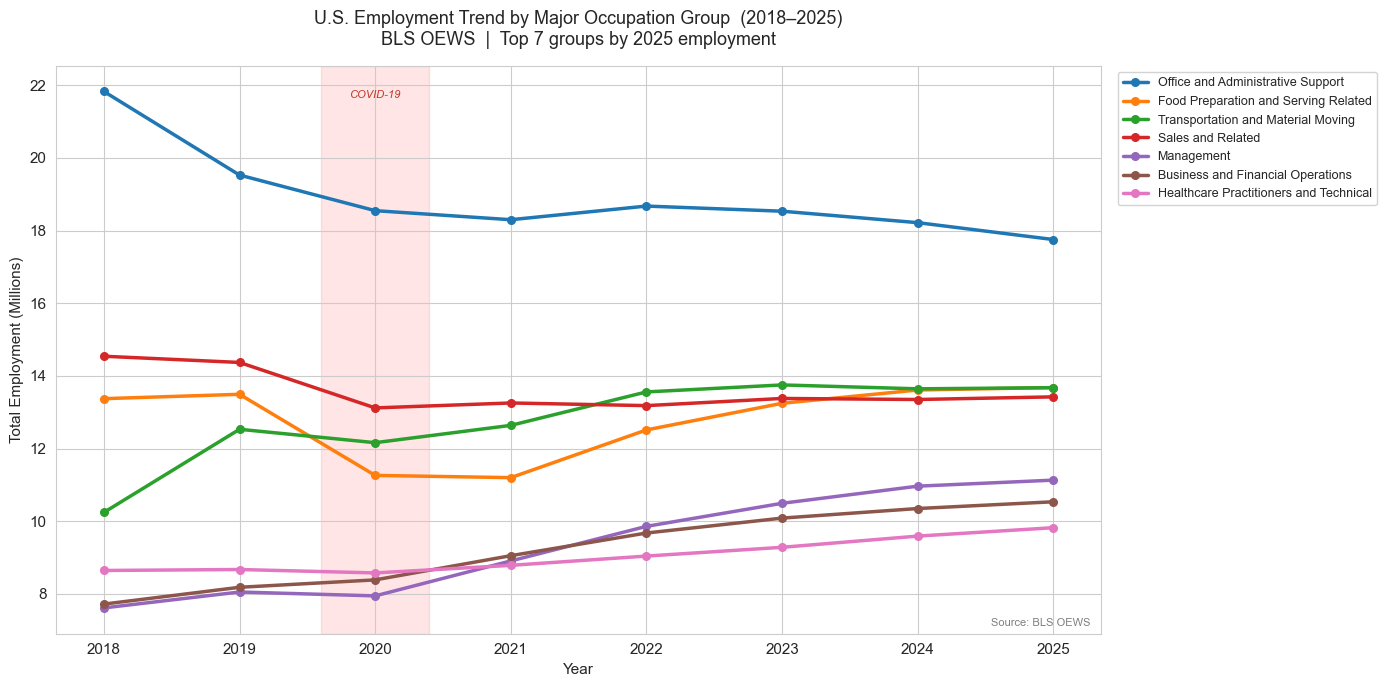

✓ Saved: 02_employment_trend_2018_2025.png


In [9]:
# ── Cell 1.4: Chart — YoY Trend Line Chart ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

palette = sns.color_palette("tab10", len(top_7_groups))
for i, group in enumerate(top_7_groups):
    data = df_trend_filtered[df_trend_filtered['short_title'] == group].sort_values('year')
    ax.plot(data['year'], data['tot_emp'] / 1e6,
            marker='o', linewidth=2.5, markersize=5.5,
            label=group, color=palette[i])

# Flag 2020 COVID distortion visually
ax.axvspan(2019.6, 2020.4, alpha=0.10, color='red', zorder=0)
ax.text(2020, ax.get_ylim()[1] * 0.97, 'COVID-19',
        fontsize=8, color='#c0392b', ha='center', va='top', fontstyle='italic')

ax.set_xlabel("Year")
ax.set_ylabel("Total Employment (Millions)")
ax.set_title("U.S. Employment Trend by Major Occupation Group  (2018–2025)\nBLS OEWS  |  Top 7 groups by 2025 employment", pad=15)
ax.set_xticks(range(2018, 2026))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, framealpha=0.85)
ax.text(0.99, 0.01, "Source: BLS OEWS",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/02_employment_trend_2018_2025.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 02_employment_trend_2018_2025.png")

In [10]:
# ── Cell 1.5: Load Wage Data ──────────────────────────────────────────────────
# Pull a_mean as raw text — don't CAST in SQL.
# pd.to_numeric(errors='coerce') handles all suppression flags (* ** # *** ~ etc.)
# by converting any non-numeric value to NaN, which we then drop.

query_wages = f"""
    SELECT occ_code, occ_title, a_mean
    FROM bls_oews
    WHERE year      = 2025
      AND data_type = 'national'
      AND {DETAILED_FILTER}
      AND a_mean IS NOT NULL
"""
df_wages = pd.read_sql(query_wages, engine)
df_wages['a_mean'] = pd.to_numeric(df_wages['a_mean'], errors='coerce')
df_wages = df_wages.dropna(subset=['a_mean'])

print(f"Occupations with valid wage data: {len(df_wages):,}")
print(f"\nWage summary (annual mean):")
print(df_wages['a_mean'].describe().apply(lambda x: f"${x:,.0f}"))

Occupations with valid wage data: 818

Wage summary (annual mean):
count        $818
mean      $80,417
std       $51,852
min       $31,980
25%       $50,272
50%       $66,445
75%       $91,648
max      $502,050
Name: a_mean, dtype: str


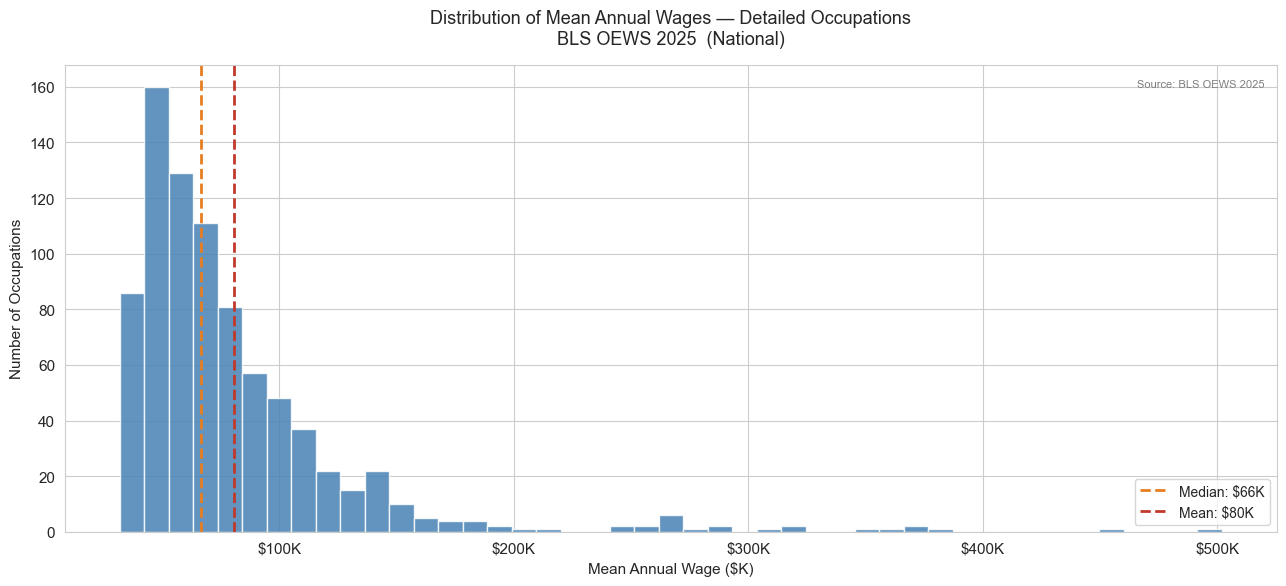

✓ Saved: 03_wage_distribution_2025.png


In [11]:
# ── Cell 1.6: Chart — Wage Distribution Histogram ────────────────────────────
median_wage = df_wages['a_mean'].median()
mean_wage   = df_wages['a_mean'].mean()

fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(df_wages['a_mean'] / 1000, bins=45, color='steelblue', edgecolor='white', alpha=0.85)

ax.axvline(median_wage / 1000, color='#e67e22', linestyle='--', linewidth=2,
           label=f'Median: ${median_wage/1000:.0f}K')
ax.axvline(mean_wage / 1000, color='#c0392b', linestyle='--', linewidth=2,
           label=f'Mean: ${mean_wage/1000:.0f}K')

ax.set_xlabel("Mean Annual Wage ($K)")
ax.set_ylabel("Number of Occupations")
ax.set_title("Distribution of Mean Annual Wages — Detailed Occupations\nBLS OEWS 2025  (National)", pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(fontsize=10)
ax.text(0.99, 0.97, "Source: BLS OEWS 2025",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/03_wage_distribution_2025.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 03_wage_distribution_2025.png")

In [12]:
# ── Cell 1.7: Load Metro Employment Data ─────────────────────────────────────
# Pull raw text, convert in Python — avoids the SQL CAST crash on suppression flags
query_metros = f"""
    SELECT area_title, tot_emp
    FROM bls_oews
    WHERE year      = 2025
      AND data_type = 'msa'
      AND {DETAILED_FILTER}
      AND tot_emp IS NOT NULL
"""
df_metros_raw = pd.read_sql(query_metros, engine)
df_metros_raw['tot_emp'] = pd.to_numeric(df_metros_raw['tot_emp'], errors='coerce')
df_metros_raw = df_metros_raw.dropna(subset=['tot_emp'])

df_metros = (
    df_metros_raw
    .groupby('area_title', as_index=False)['tot_emp']
    .sum()
    .rename(columns={'tot_emp': 'total_emp'})
    .nlargest(15, 'total_emp')
    .reset_index(drop=True)
)
df_metros['short_area'] = (
    df_metros['area_title']
    .str.split(',').str[0]
    .str.split('-').str[0]
    .str.strip()
)
print(df_metros[['short_area', 'total_emp']].to_string(index=False))

   short_area  total_emp
     New York  8715300.0
  Los Angeles  5760760.0
      Chicago  4305950.0
       Dallas  3913330.0
      Houston  3142870.0
   Washington  3008390.0
      Atlanta  2773030.0
 Philadelphia  2690520.0
        Miami  2669410.0
       Boston  2551370.0
      Phoenix  2252820.0
San Francisco  2196240.0
      Seattle  1983350.0
  Minneapolis  1796900.0
      Detroit  1770170.0


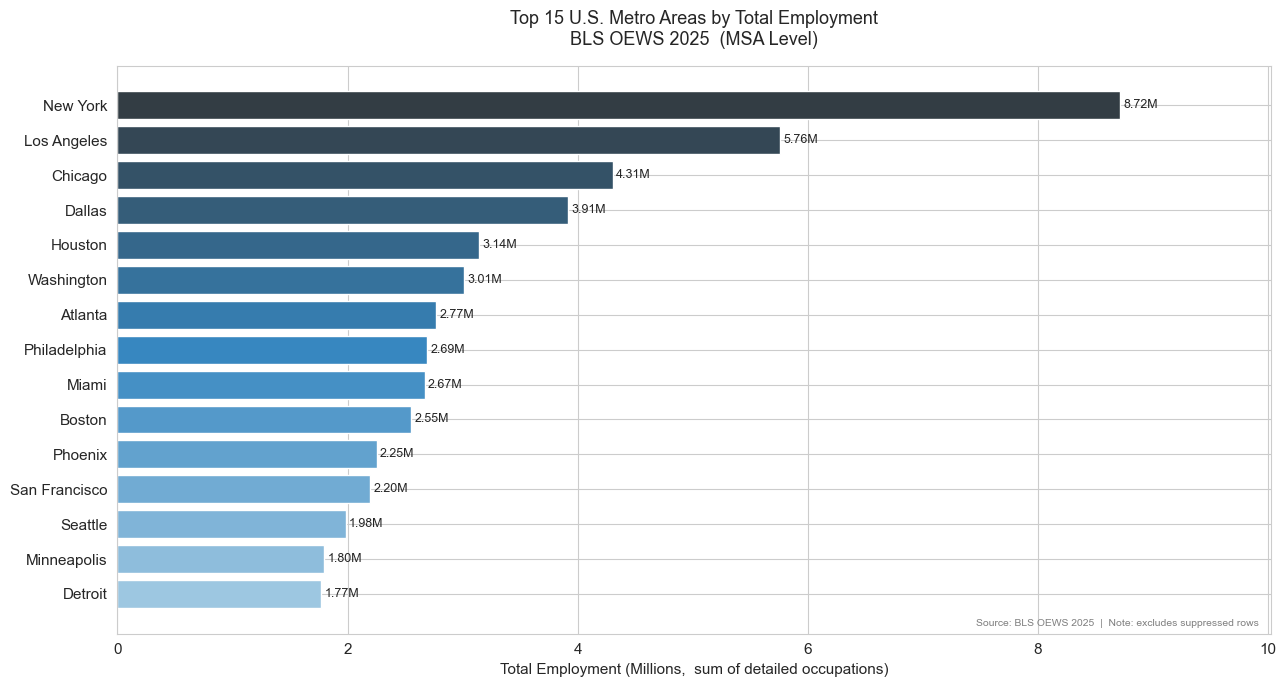

✓ Saved: 04_top15_metros_employment.png


In [13]:
# ── Cell 1.8: Chart — Top 15 Metro Areas by Employment ───────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.barh(
    y     = df_metros['short_area'][::-1].values,
    width = df_metros['total_emp'][::-1].values / 1e6,
    color = sns.color_palette("Blues_d", len(df_metros))
)

for bar, val in zip(bars, df_metros['total_emp'][::-1].values):
    ax.text(bar.get_width() + 0.03,
            bar.get_y() + bar.get_height() / 2,
            f"{val/1e6:.2f}M", va='center', fontsize=9)

ax.set_xlim(0, df_metros['total_emp'].max() / 1e6 * 1.15)
ax.set_xlabel("Total Employment (Millions,  sum of detailed occupations)")
ax.set_title("Top 15 U.S. Metro Areas by Total Employment\nBLS OEWS 2025  (MSA Level)", pad=15)
ax.text(0.99, 0.01, "Source: BLS OEWS 2025  |  Note: excludes suppressed rows",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=7.5, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/04_top15_metros_employment.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 04_top15_metros_employment.png")

In [14]:
# ── Cell 1.9: Suppression Rate Analysis ──────────────────────────────────────
# Pull year + tot_emp as raw text, classify in Python.
# Catches ALL suppression flags (*, **, #, ***, etc.) — not just the known ones.
query_supp = f"""
    SELECT year, tot_emp
    FROM bls_oews
    WHERE data_type = 'msa'
      AND {DETAILED_FILTER}
"""
df_supp_raw = pd.read_sql(query_supp, engine)
df_supp_raw['is_numeric'] = pd.to_numeric(df_supp_raw['tot_emp'], errors='coerce').notna()

df_suppression = (
    df_supp_raw
    .groupby('year')
    .agg(
        total_rows      = ('tot_emp',    'count'),
        suppressed_rows = ('is_numeric', lambda x: (~x).sum())
    )
    .reset_index()
)
df_suppression['suppressed_pct'] = (
    df_suppression['suppressed_rows'] / df_suppression['total_rows'] * 100
).round(2)

print("BLS OEWS Suppression Rate — MSA Detailed Rows:")
print(df_suppression.to_string(index=False))

BLS OEWS Suppression Rate — MSA Detailed Rows:
 year  total_rows  suppressed_rows  suppressed_pct
 2018      133848            12531            9.36
 2019      130138            11439            8.79
 2020      127811            11372            8.90
 2021      136116             2398            1.76
 2022      137092             1901            1.39
 2023      138490             2076            1.50
 2024      139108             2941            2.11
 2025      138961             2895            2.08


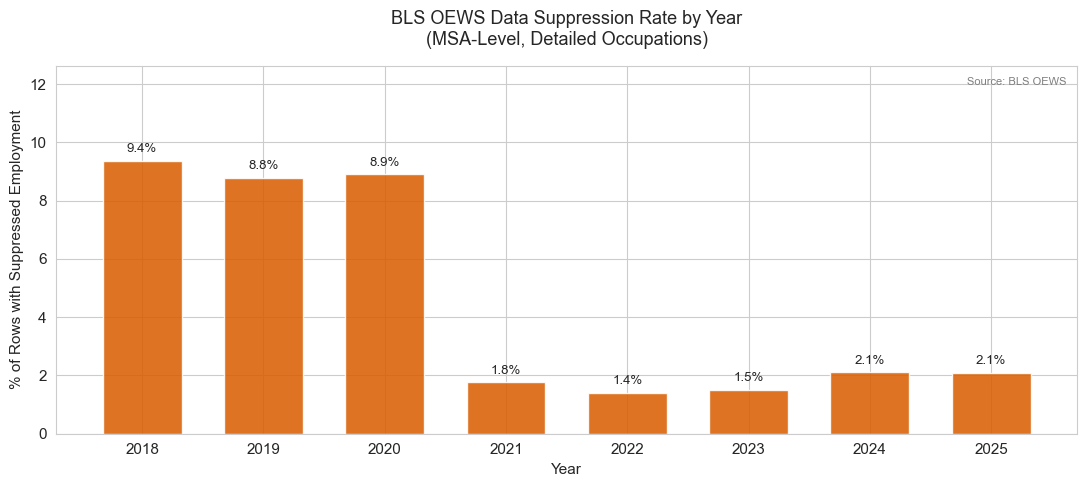

✓ Saved: 05_suppression_rate_by_year.png


In [15]:
# ── Cell 1.10: Chart — Suppression Rate by Year ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(df_suppression['year'], df_suppression['suppressed_pct'],
       color='#d95f02', edgecolor='white', alpha=0.87, width=0.65)

for _, row in df_suppression.iterrows():
    ax.text(row['year'], row['suppressed_pct'] + 0.3,
            f"{row['suppressed_pct']:.1f}%", ha='center', fontsize=9.5)

ax.set_xlabel("Year")
ax.set_ylabel("% of Rows with Suppressed Employment")
ax.set_title("BLS OEWS Data Suppression Rate by Year\n(MSA-Level, Detailed Occupations)", pad=15)
ax.set_xticks(range(2018, 2026))
ax.set_ylim(0, df_suppression['suppressed_pct'].max() * 1.35)
ax.text(0.99, 0.97, "Source: BLS OEWS",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/05_suppression_rate_by_year.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 05_suppression_rate_by_year.png")

### ⚠️ 2020 Data Quality Note
The 2020 BLS OEWS data is significantly COVID-distorted. The survey period coincided with
peak pandemic disruption, causing widespread employment collapses that reversed within 12–18 months.

**Strategy for Parts 5–6:**
- Keep 2020 in the dataset but add an `is_covid_year` binary flag feature
- For YoY change calculations, use 2019→2021 as a skip-year change rather than any interval crossing 2020
- Do not let the forecasting model treat the 2020 dip as a structural break

## Section 2 — Automation Risk Distribution EDA

Exploring the Frey & Osborne (2013) automation probability scores.
702 occupations rated 0.00–1.00 on probability of automation within ~20 years.

Risk tiers:
- **Low:** 0.00–0.30
- **Medium:** 0.30–0.70
- **High:** 0.70–1.00

In [16]:
# ── Cell 2.1: Load Automation Scores ─────────────────────────────────────────
df_auto = pd.read_sql("SELECT * FROM automation_scores", engine)

print(f"Rows loaded: {len(df_auto):,}")
print(f"\nNull counts:")
print(df_auto.isnull().sum())
print(f"\nSample rows:")
print(df_auto.head(3).to_string())

Rows loaded: 702

Null counts:
id                 0
occ_code           0
occ_title          0
automation_prob    0
median_wage        0
education_req      0
dtype: int64

Sample rows:
   id occ_code                                                                                                occ_title  automation_prob  median_wage                      education_req
0   1  51-4033  Grinding, Lapping, Polishing and Buffing Machine Tool Setters, Operators and Tenders, Metal and Plastic             0.95      32890.0  High school diploma or equivalent
1   2  51-9012        Separating, Filtering, Clarifying, Precipitating and Still Machine Setters, Operators and Tenders             0.88      38360.0  High school diploma or equivalent
2   3  41-4012             Sales Representatives, Wholesale and Manufacturing, Except Technical and Scientific Products             0.85      57140.0  High school diploma or equivalent


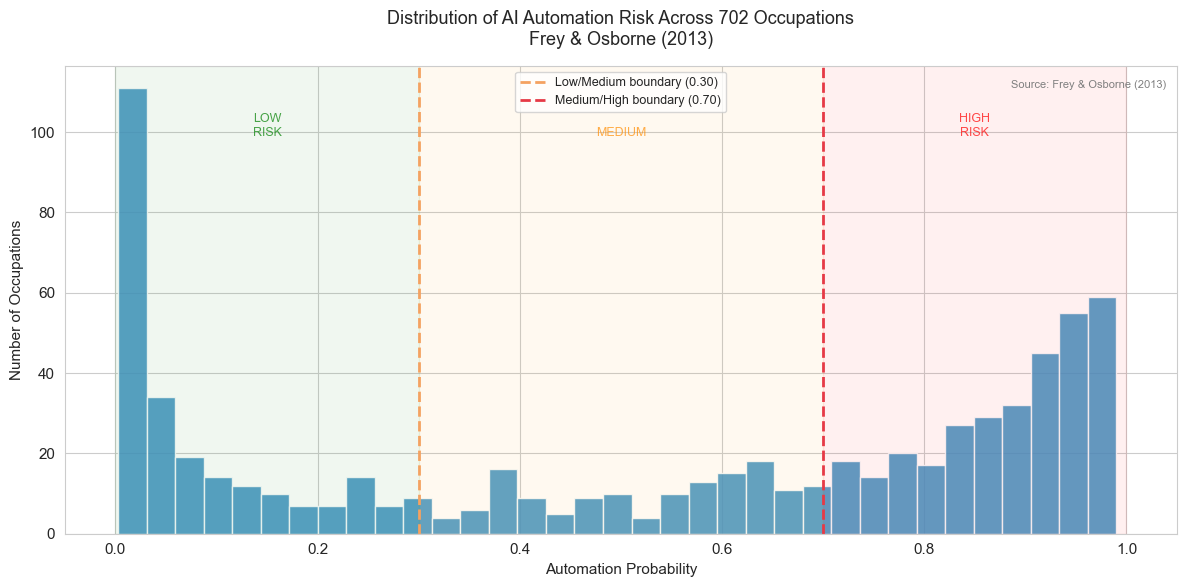

✓ Saved: 06_automation_prob_distribution.png


In [17]:
# ── Cell 2.2: Chart — Automation Probability Distribution ────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df_auto['automation_prob'], bins=35, color='#4393c3', edgecolor='white', alpha=0.87)

ax.axvline(0.30, color='#f4a261', linestyle='--', linewidth=2, label='Low/Medium boundary (0.30)')
ax.axvline(0.70, color='#e63946', linestyle='--', linewidth=2, label='Medium/High boundary (0.70)')

ax.axvspan(0.00, 0.30, alpha=0.06, color='green')
ax.axvspan(0.30, 0.70, alpha=0.06, color='orange')
ax.axvspan(0.70, 1.00, alpha=0.06, color='red')

ax.text(0.15, ax.get_ylim()[1] * 0.85, 'LOW\nRISK',  ha='center', fontsize=9, color='green',      alpha=0.7)
ax.text(0.50, ax.get_ylim()[1] * 0.85, 'MEDIUM',      ha='center', fontsize=9, color='darkorange', alpha=0.7)
ax.text(0.85, ax.get_ylim()[1] * 0.85, 'HIGH\nRISK', ha='center', fontsize=9, color='red',        alpha=0.7)

ax.set_xlabel("Automation Probability")
ax.set_ylabel("Number of Occupations")
ax.set_title("Distribution of AI Automation Risk Across 702 Occupations\nFrey & Osborne (2013)", pad=15)
ax.legend(fontsize=9)
ax.text(0.99, 0.97, "Source: Frey & Osborne (2013)",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/06_automation_prob_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 06_automation_prob_distribution.png")

In [18]:
# ── Cell 2.3: Classify Risk Tiers ────────────────────────────────────────────
df_auto['risk_tier'] = pd.cut(
    df_auto['automation_prob'],
    bins   = [0.0, 0.30, 0.70, 1.01],
    labels = ['Low (0–30%)', 'Medium (30–70%)', 'High (70–100%)'],
    right  = True
)

tier_counts = df_auto['risk_tier'].value_counts().sort_index()
print("Occupation count by risk tier:")
print(tier_counts.to_string())
print(f"\n→ {tier_counts['High (70–100%)'] / len(df_auto) * 100:.1f}% of the 702 occupations are high-risk")

Occupation count by risk tier:
risk_tier
Low (0–30%)        241
Medium (30–70%)    145
High (70–100%)     316

→ 45.0% of the 702 occupations are high-risk


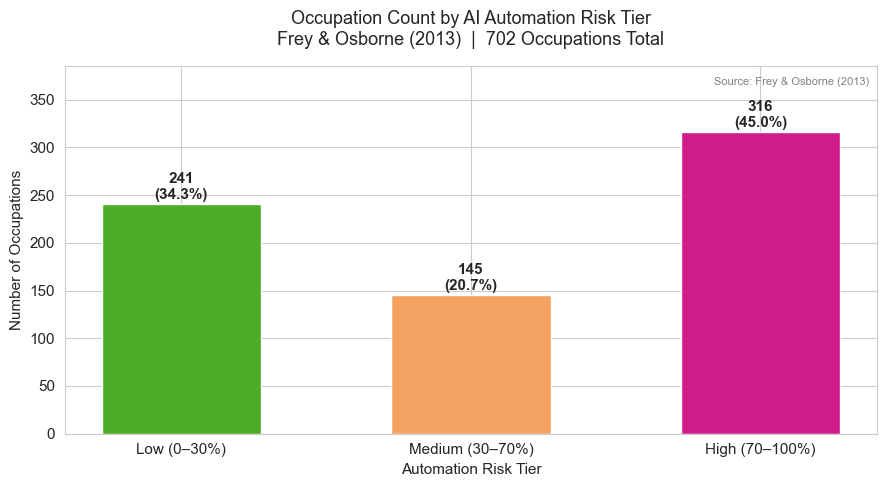

✓ Saved: 07_risk_tier_counts.png


In [19]:
# ── Cell 2.4: Chart — Risk Tier Count Bar Chart ───────────────────────────────
tier_order  = ['Low (0–30%)', 'Medium (30–70%)', 'High (70–100%)']
tier_colors = ['#4dac26', '#f4a261', '#d01c8b']
tier_data   = tier_counts.reindex(tier_order)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(tier_data.index, tier_data.values,
              color=tier_colors, edgecolor='white', width=0.55)

for bar, val in zip(bars, tier_data.values):
    pct = val / len(df_auto) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{val}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, tier_data.max() * 1.22)
ax.set_xlabel("Automation Risk Tier")
ax.set_ylabel("Number of Occupations")
ax.set_title("Occupation Count by AI Automation Risk Tier\nFrey & Osborne (2013)  |  702 Occupations Total", pad=15)
ax.text(0.99, 0.97, "Source: Frey & Osborne (2013)",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/07_risk_tier_counts.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 07_risk_tier_counts.png")

In [20]:
# ── Cell 2.5: Risk by Education — Setup ──────────────────────────────────────
edu_order = [
    'Less than high school',
    'High school diploma or equivalent',
    'Postsecondary nondegree award',
    'Some college, no degree',
    "Associate's degree",
    "Bachelor's degree",
    "Master's degree",
    'Doctoral or professional degree',
]

df_edu = df_auto.dropna(subset=['education_req', 'automation_prob'])
edu_present = [e for e in edu_order if e in df_edu['education_req'].values]

if len(edu_present) < 2:
    edu_present = sorted(df_edu['education_req'].dropna().unique().tolist())
    print("Note: Using all present education labels:")
    print(edu_present)

df_edu_plot = df_edu[df_edu['education_req'].isin(edu_present)]
print(f"Education categories found: {df_edu_plot['education_req'].nunique()}")
print(f"Valid rows: {len(df_edu_plot):,}")

Education categories found: 7
Valid rows: 604


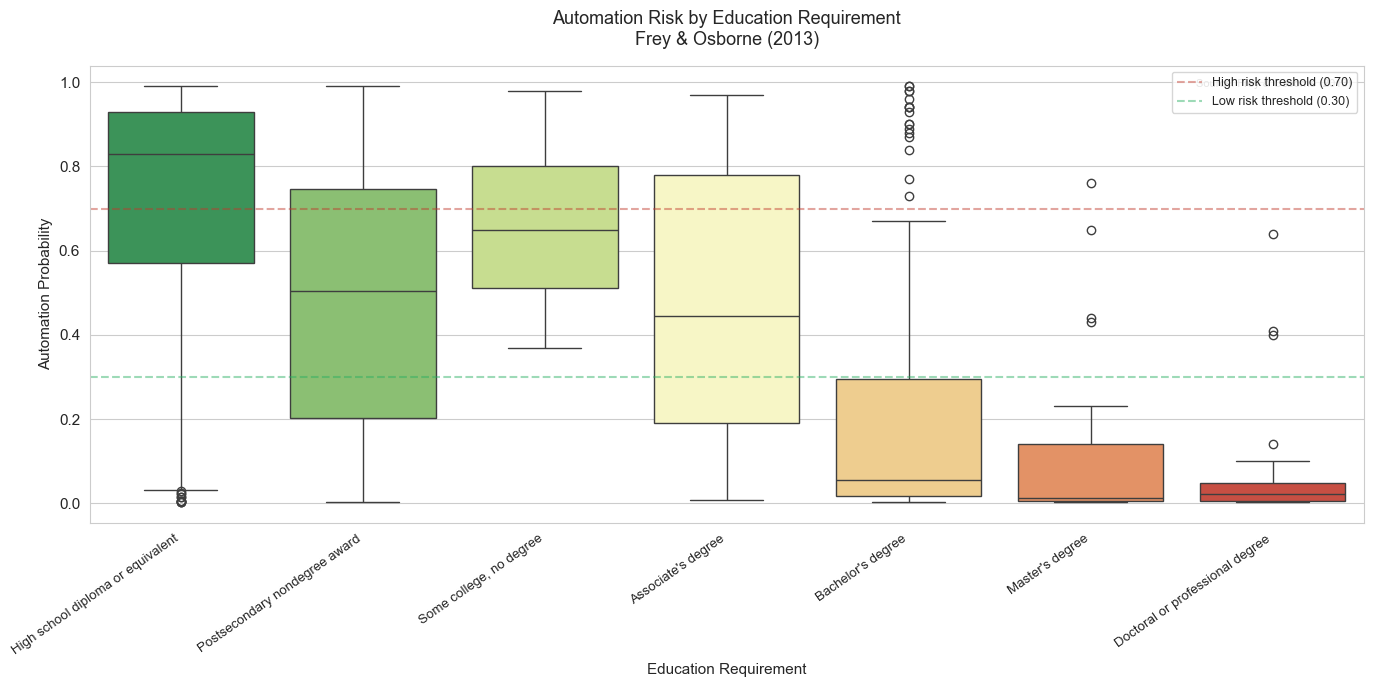

✓ Saved: 08_risk_by_education.png


In [21]:
# ── Cell 2.6: Chart — Risk by Education Box Plot ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data    = df_edu_plot,
    x       = 'education_req',
    y       = 'automation_prob',
    order   = edu_present,
    palette = 'RdYlGn_r',
    ax      = ax
)

ax.axhline(0.70, color='#c0392b', linestyle='--', alpha=0.45, linewidth=1.5, label='High risk threshold (0.70)')
ax.axhline(0.30, color='#27ae60', linestyle='--', alpha=0.45, linewidth=1.5, label='Low risk threshold (0.30)')

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9.5)
ax.set_xlabel("Education Requirement")
ax.set_ylabel("Automation Probability")
ax.set_title("Automation Risk by Education Requirement\nFrey & Osborne (2013)", pad=15)
ax.legend(fontsize=9)
ax.text(0.99, 0.97, "Source: Frey & Osborne (2013)",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/08_risk_by_education.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 08_risk_by_education.png")

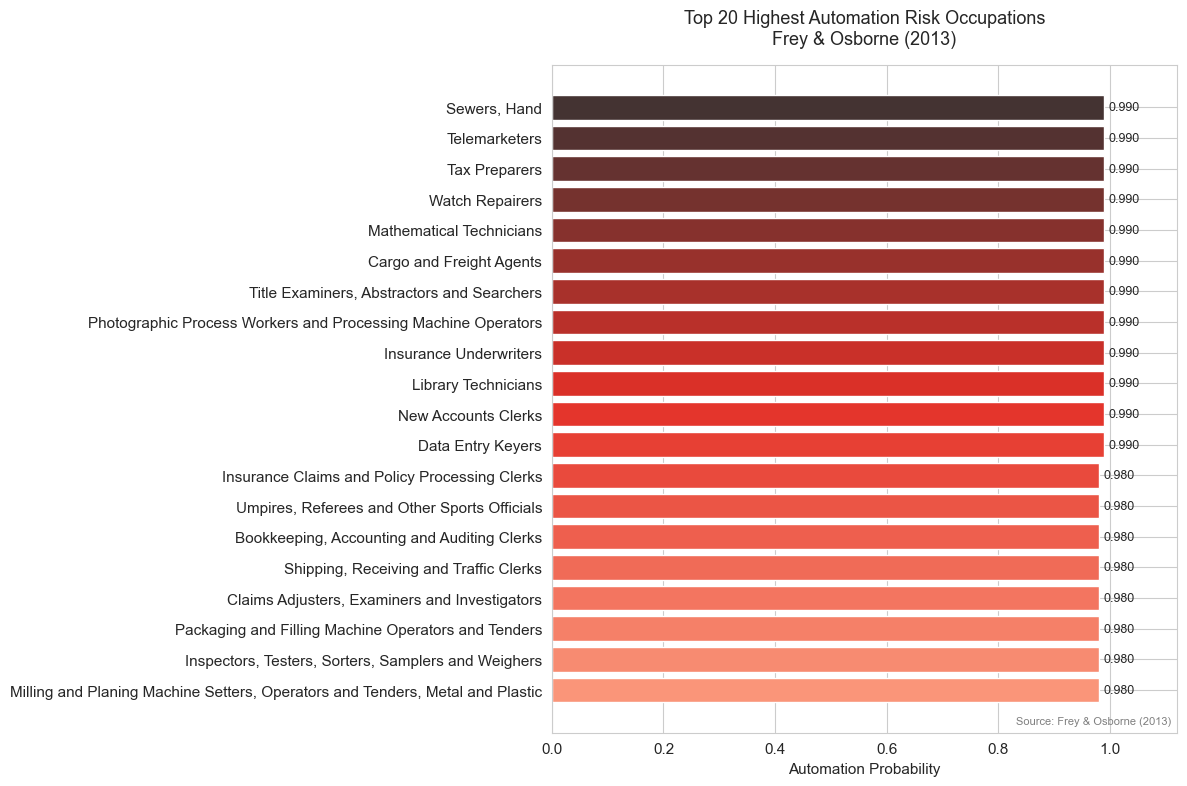

✓ Saved: 09_top20_highest_risk.png


In [22]:
# ── Cell 2.7: Chart — Top 20 Highest-Risk Occupations ────────────────────────
df_high = df_auto.nlargest(20, 'automation_prob').sort_values('automation_prob')

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_high['occ_title'], df_high['automation_prob'],
               color=sns.color_palette("Reds_d", 20))

for bar, val in zip(bars, df_high['automation_prob']):
    ax.text(bar.get_width() + 0.008,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va='center', fontsize=9)

ax.set_xlim(0, 1.12)
ax.set_xlabel("Automation Probability")
ax.set_title("Top 20 Highest Automation Risk Occupations\nFrey & Osborne (2013)", pad=15)
ax.text(0.99, 0.01, "Source: Frey & Osborne (2013)",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/09_top20_highest_risk.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 09_top20_highest_risk.png")


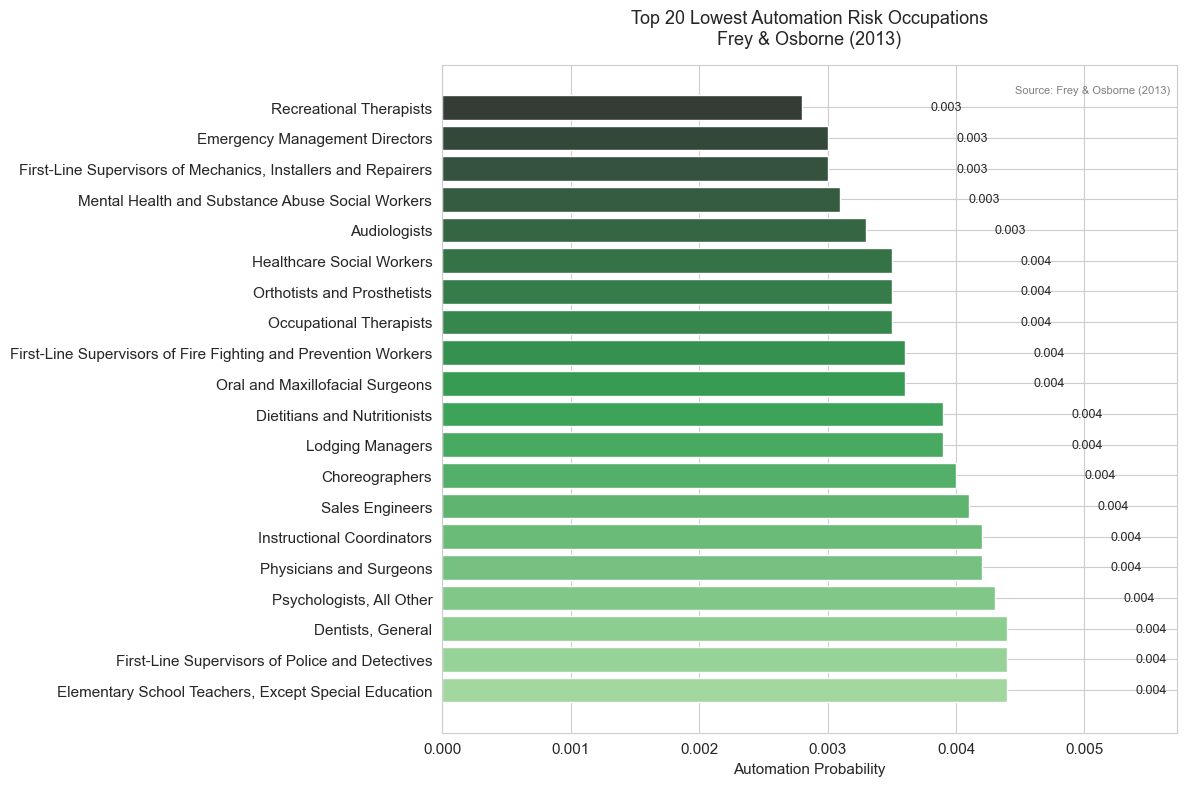

✓ Saved: 10_top20_lowest_risk.png


In [23]:
# ── Cell 2.8: Chart — Top 20 Lowest-Risk Occupations ─────────────────────────
df_low = df_auto.nsmallest(20, 'automation_prob').sort_values('automation_prob', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_low['occ_title'], df_low['automation_prob'],
               color=sns.color_palette("Greens_d", 20))

for bar, val in zip(bars, df_low['automation_prob']):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va='center', fontsize=9)

ax.set_xlim(0, df_low['automation_prob'].max() * 1.3)
ax.set_xlabel("Automation Probability")
ax.set_title("Top 20 Lowest Automation Risk Occupations\nFrey & Osborne (2013)", pad=15)
ax.text(0.99, 0.97, "Source: Frey & Osborne (2013)",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/10_top20_lowest_risk.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 10_top20_lowest_risk.png")

### Coverage Note
Frey & Osborne covers **702 occupations** based on 2010 SOC codes. BLS OEWS has newer
occupation titles (Data Scientists, Cybersecurity Analysts, etc.) that didn't exist in 2013.
These ~15–20% of occupations without a score will be handled in Part 5 via median imputation
by major occupation group.

## Section 3 — O*NET Work Activities EDA

O*NET rates each occupation on ~40 standardized work activities using two scales:
- **IM (Importance):** 1–5 — how central is this activity to the job?
- **LV (Level):** 0–7 — at what expertise level is it performed?

We use **Importance (IM)** throughout. It captures whether an activity defines a role,
not just how skilled the practitioner is at it.

In [24]:
# ── Cell 3.1: O*NET Basic Summary Stats ──────────────────────────────────────
df_onet_im = pd.read_sql("""
    SELECT * FROM onet_work_activities
    WHERE scale_id = 'IM'
""", engine)

print("=== O*NET Work Activities — Importance (IM) Scale ===")
print(f"  Total rows:                  {len(df_onet_im):,}")
print(f"  Unique occupations:          {df_onet_im['onet_soc_code'].nunique():,}")
print(f"  Unique activities:           {df_onet_im['element_name'].nunique()}")
print(f"  Score range:                 {df_onet_im['data_value'].min():.2f} – {df_onet_im['data_value'].max():.2f}")
print(f"\nTop 12 most common activities:")
print(df_onet_im['element_name'].value_counts().head(12).to_string())

=== O*NET Work Activities — Importance (IM) Scale ===
  Total rows:                  36,654
  Unique occupations:          894
  Unique activities:           41
  Score range:                 1.00 – 4.99

Top 12 most common activities:
element_name
Getting Information                                                                894
Monitoring Processes, Materials, or Surroundings                                   894
Identifying Objects, Actions, and Events                                           894
Inspecting Equipment, Structures, or Materials                                     894
Estimating the Quantifiable Characteristics of Products, Events, or Information    894
Judging the Qualities of Objects, Services, or People                              894
Processing Information                                                             894
Evaluating Information to Determine Compliance with Standards                      894
Analyzing Data or Information                          

In [25]:
# ── Cell 3.2: Identify Top 10 Most Common Activities ─────────────────────────
top10_activities = df_onet_im['element_name'].value_counts().head(10).index.tolist()
df_top10 = df_onet_im[df_onet_im['element_name'].isin(top10_activities)].copy()

name_map = {
    "Making Decisions and Solving Problems"                    : "Decision Making",
    "Getting Information"                                      : "Getting Information",
    "Communicating with Supervisors, Peers, or Subordinates"   : "Internal Communication",
    "Interacting With Computers"                               : "Computer Interaction",
    "Documenting/Recording Information"                        : "Documenting/Recording",
    "Processing Information"                                   : "Processing Information",
    "Organizing, Planning, and Prioritizing Work"              : "Planning & Prioritizing",
    "Evaluating Information to Determine Compliance with Standards": "Compliance Evaluation",
    "Updating and Using Relevant Knowledge"                    : "Knowledge Updating",
    "Communicating with People Outside the Organization"       : "External Communication",
}
df_top10['short_name'] = df_top10['element_name'].map(name_map).fillna(df_top10['element_name'])
print(f"Top 10 activities identified: {top10_activities[:3]}...")

Top 10 activities identified: ['Getting Information', 'Monitoring Processes, Materials, or Surroundings', 'Identifying Objects, Actions, and Events']...


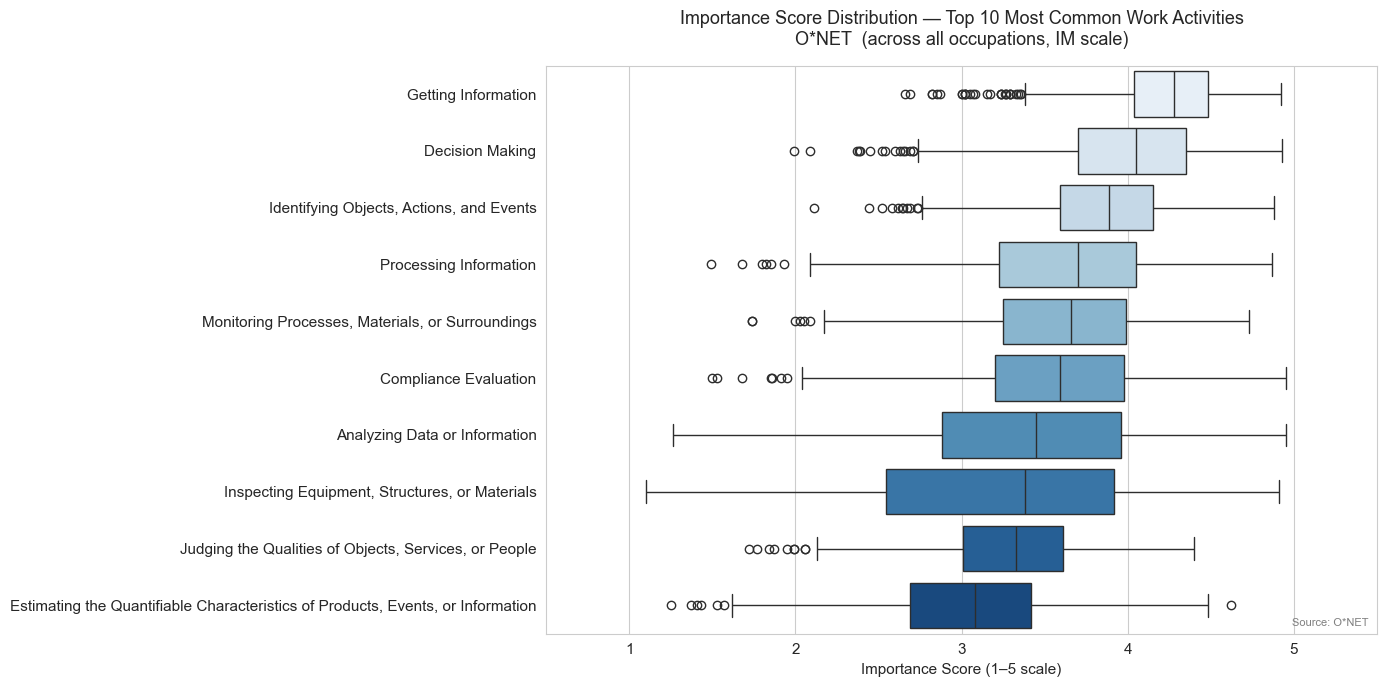

✓ Saved: 11_onet_top10_activity_boxplots.png


In [26]:
# ── Cell 3.3: Chart — Box Plots for Top 10 Activities ────────────────────────
activity_medians = (
    df_top10.groupby('short_name')['data_value']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data    = df_top10,
    x       = 'data_value',
    y       = 'short_name',
    order   = activity_medians,
    palette = 'Blues',
    orient  = 'h',
    ax      = ax
)

ax.set_xlabel("Importance Score (1–5 scale)")
ax.set_ylabel("")
ax.set_title("Importance Score Distribution — Top 10 Most Common Work Activities\nO*NET  (across all occupations, IM scale)", pad=15)
ax.set_xlim(0.5, 5.5)
ax.text(0.99, 0.01, "Source: O*NET",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/11_onet_top10_activity_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 11_onet_top10_activity_boxplots.png")

In [27]:
# ── Cell 3.4: Average Importance Across All Activities ────────────────────────
df_activity_avg = (
    df_onet_im
    .groupby('element_name')['data_value']
    .mean()
    .reset_index()
    .rename(columns={'data_value': 'avg_importance'})
    .sort_values('avg_importance', ascending=False)
)

print(f"Total unique activities: {len(df_activity_avg)}")
print(df_activity_avg.head(8).to_string(index=False))

Total unique activities: 41
                                            element_name  avg_importance
                                     Getting Information        4.222483
  Communicating with Supervisors, Peers, or Subordinates        4.004474
                   Making Decisions and Solving Problems        3.988669
                Identifying Objects, Actions, and Events        3.844664
                   Updating and Using Relevant Knowledge        3.778680
             Organizing, Planning, and Prioritizing Work        3.697081
Establishing and Maintaining Interpersonal Relationships        3.683345
                       Documenting/Recording Information        3.643400


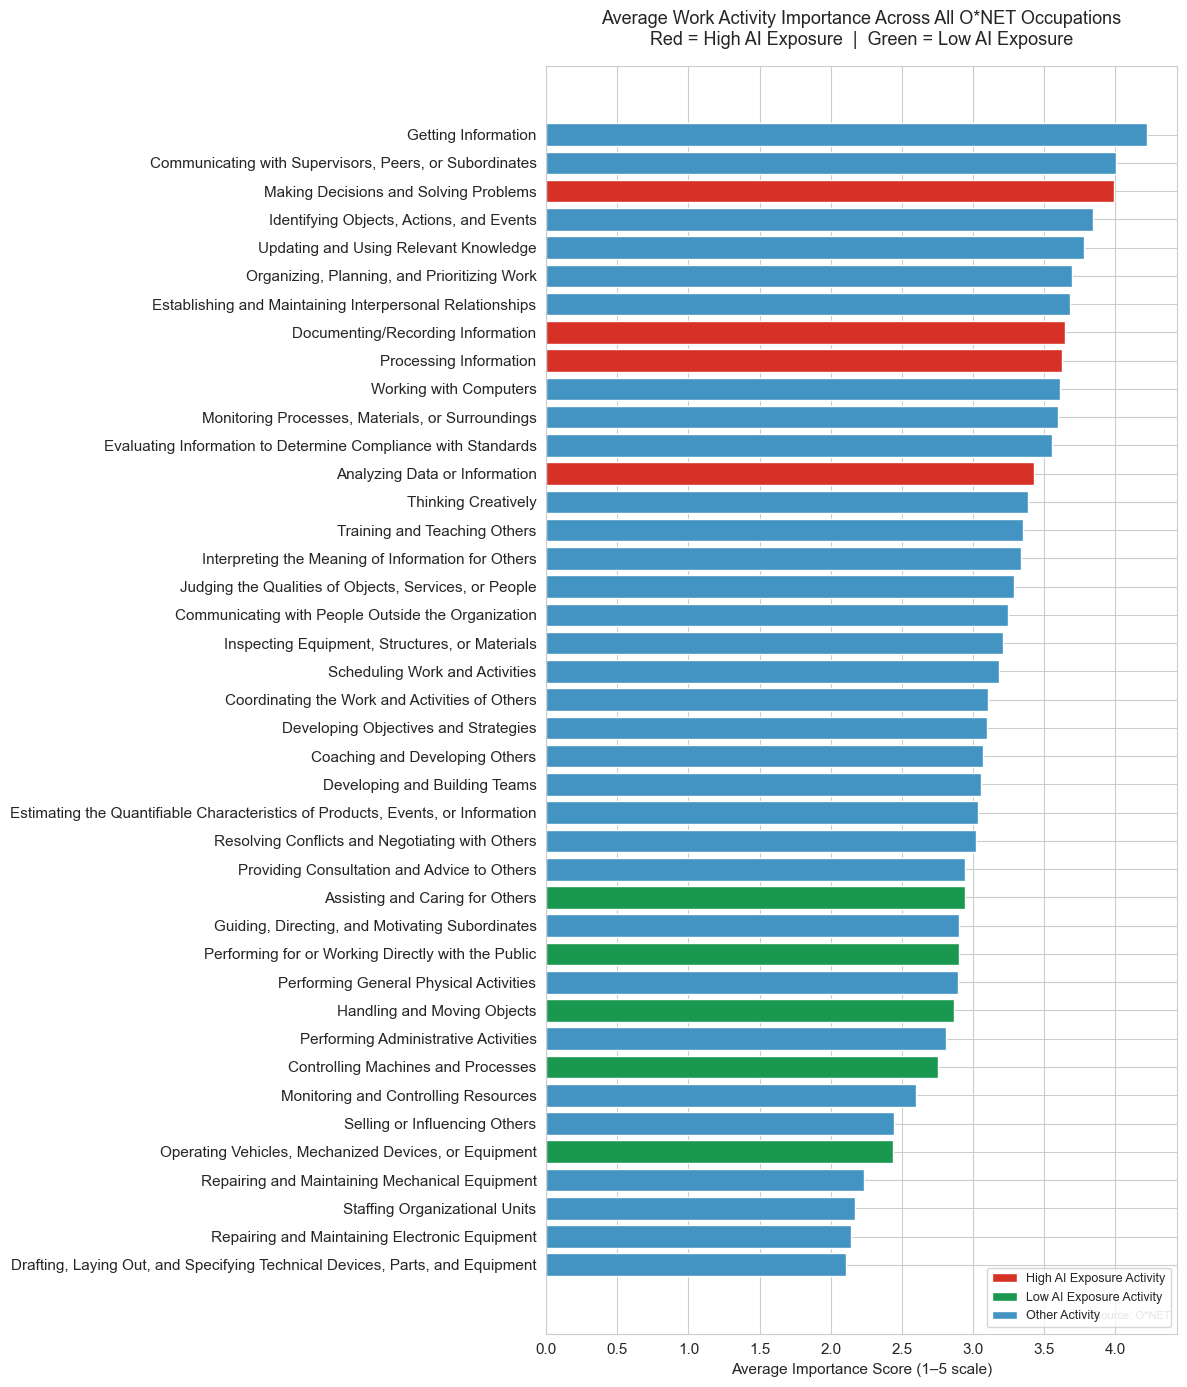

✓ Saved: 12_onet_avg_importance_all_activities.png


In [28]:
# ── Cell 3.5: Chart — Avg Importance per Activity (color-coded) ───────────────
high_ai = [
    "Processing Information", "Analyzing Data or Information",
    "Documenting/Recording Information", "Interacting With Computers",
    "Making Decisions and Solving Problems",
]
low_ai = [
    "Assisting and Caring for Others",
    "Performing for or Working Directly with the Public",
    "Handling and Moving Objects",
    "Operating Vehicles, Mechanized Devices, or Equipment",
    "Controlling Machines and Processes",
]

colors = []
for activity in df_activity_avg['element_name']:
    if activity in high_ai:   colors.append('#d73027')
    elif activity in low_ai:  colors.append('#1a9850')
    else:                     colors.append('#4393c3')

fig, ax = plt.subplots(figsize=(12, 14))
ax.barh(df_activity_avg['element_name'], df_activity_avg['avg_importance'], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Average Importance Score (1–5 scale)")
ax.set_title("Average Work Activity Importance Across All O*NET Occupations\nRed = High AI Exposure  |  Green = Low AI Exposure", pad=15)

legend_handles = [
    Patch(facecolor='#d73027', label='High AI Exposure Activity'),
    Patch(facecolor='#1a9850', label='Low AI Exposure Activity'),
    Patch(facecolor='#4393c3', label='Other Activity'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')
ax.text(0.99, 0.01, "Source: O*NET",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/12_onet_avg_importance_all_activities.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 12_onet_avg_importance_all_activities.png")

In [29]:
# ── Cell 3.6: Join O*NET to Automation Scores ─────────────────────────────────
# O*NET soc codes: "15-1252.00"  →  LEFT(., 7) = "15-1252"
# Automation scores occ_code:    "15-1252"    →  LEFT(., 7) = "15-1252"

query_onet_auto = """
    SELECT
        o.element_name,
        o.data_value,
        a.automation_prob
    FROM onet_work_activities o
    JOIN automation_scores a
        ON LEFT(o.onet_soc_code, 7) = LEFT(a.occ_code, 7)
    WHERE o.scale_id          = 'IM'
      AND o.data_value         IS NOT NULL
      AND a.automation_prob    IS NOT NULL
"""
df_onet_auto = pd.read_sql(query_onet_auto, engine)

print(f"O*NET × Automation rows: {len(df_onet_auto):,}")
print(f"Activities represented:   {df_onet_auto['element_name'].nunique()}")

O*NET × Automation rows: 29,069
Activities represented:   41


In [30]:
# ── Cell 3.7: Build Heatmap Data ──────────────────────────────────────────────
df_onet_auto['risk_tier'] = pd.cut(
    df_onet_auto['automation_prob'],
    bins   = [0.0, 0.30, 0.70, 1.01],
    labels = ['Low', 'Medium', 'High'],
    right  = True
)

heatmap_data = (
    df_onet_auto
    .groupby(['element_name', 'risk_tier'])['data_value']
    .mean()
    .unstack('risk_tier')
)

heatmap_data['_diff'] = heatmap_data['High'] - heatmap_data['Low']
heatmap_data = heatmap_data.sort_values('_diff', ascending=False).drop(columns='_diff')

print("Top 5 activities most associated with HIGH-risk occupations:")
top_diff = heatmap_data.copy()
top_diff['diff'] = heatmap_data['High'] - heatmap_data['Low']
print(top_diff.nlargest(5, 'diff')[['Low', 'High', 'diff']].to_string())
print("\nBottom 5 (most associated with LOW-risk / human-touch occupations):")
print(top_diff.nsmallest(5, 'diff')[['Low', 'High', 'diff']].to_string())

Top 5 activities most associated with HIGH-risk occupations:
risk_tier                                                  Low      High      diff
element_name                                                                      
Handling and Moving Objects                           2.431055  3.305331  0.874277
Controlling Machines and Processes                    2.366182  3.200033  0.833851
Repairing and Maintaining Mechanical Equipment        1.896000  2.622980  0.726980
Performing General Physical Activities                2.576145  3.215199  0.639053
Operating Vehicles, Mechanized Devices, or Equipment  2.144873  2.777086  0.632213

Bottom 5 (most associated with LOW-risk / human-touch occupations):
risk_tier                                                Low      High      diff
element_name                                                                    
Working with Computers                              4.024400  3.129172 -0.895228
Communicating with People Outside the Organiza

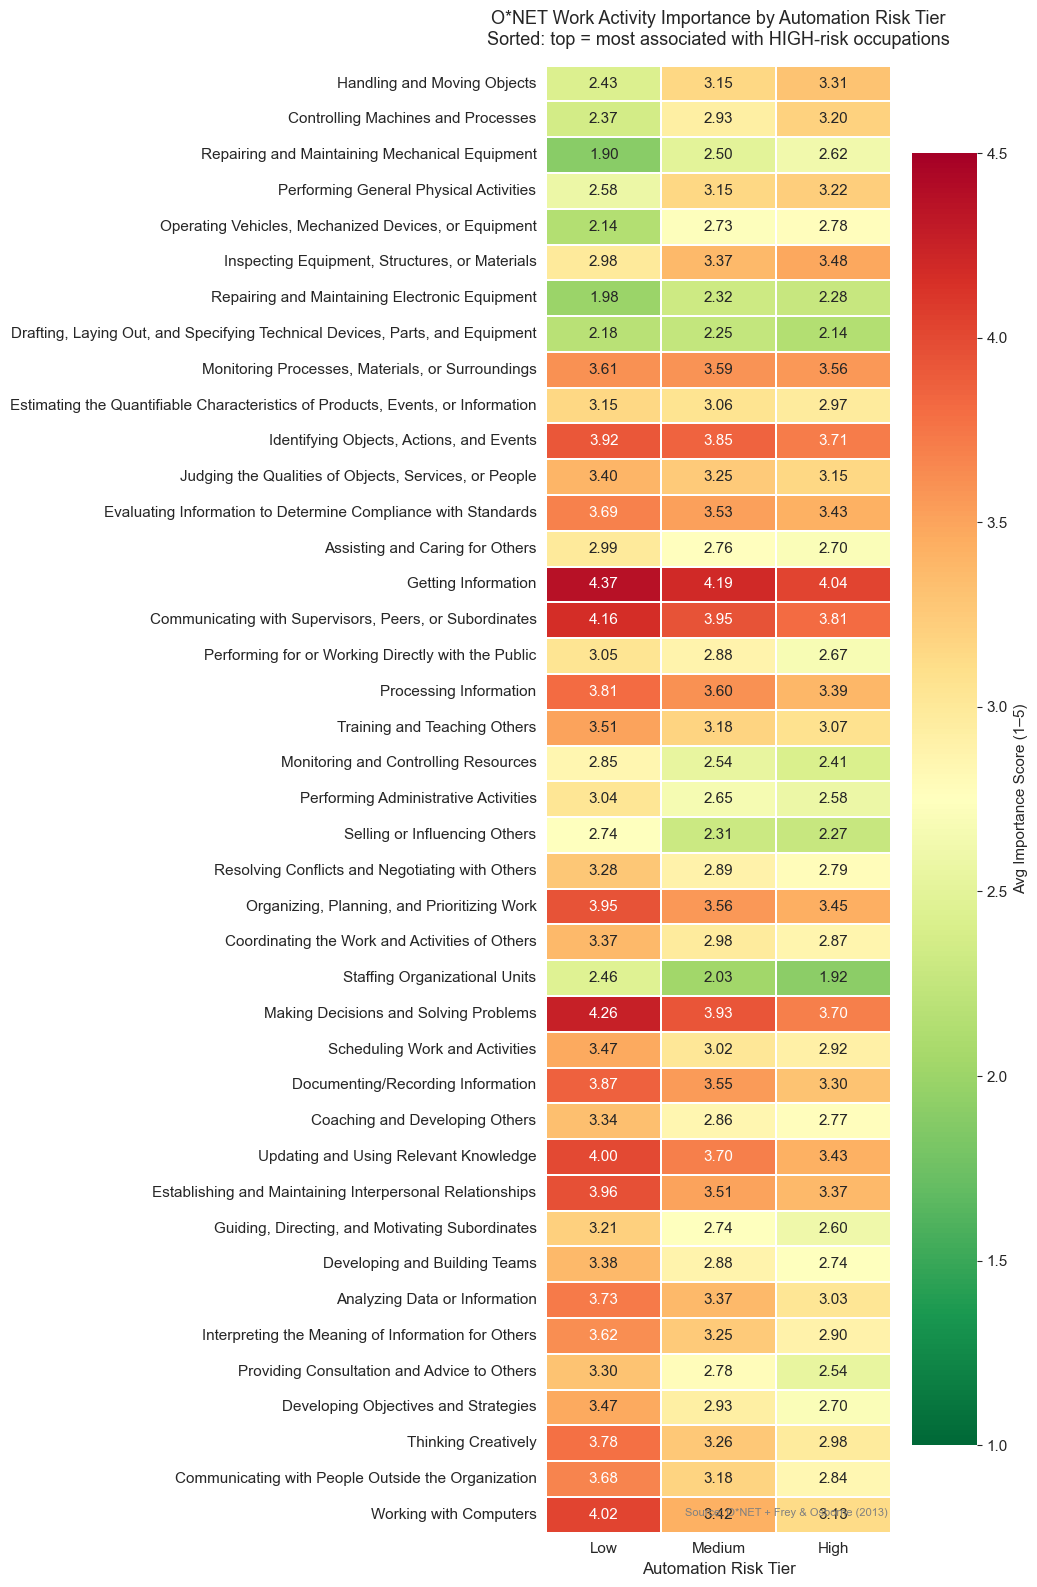

✓ Saved: 13_onet_activity_heatmap_risk_tier.png


In [31]:
# ── Cell 3.8: Chart — O*NET Activity Heatmap by Risk Tier ────────────────────
fig, ax = plt.subplots(figsize=(10, 16))

sns.heatmap(
    heatmap_data,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'RdYlGn_r',
    linewidths = 0.25,
    ax         = ax,
    cbar_kws   = {'label': 'Avg Importance Score (1–5)'},
    vmin       = 1.0,
    vmax       = 4.5
)

ax.set_xlabel("Automation Risk Tier", fontsize=12)
ax.set_ylabel("")
ax.set_title(
    "O*NET Work Activity Importance by Automation Risk Tier\n"
    "Sorted: top = most associated with HIGH-risk occupations",
    fontsize=13, pad=15
)
ax.text(0.99, 0.01, "Source: O*NET + Frey & Osborne (2013)",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/13_onet_activity_heatmap_risk_tier.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 13_onet_activity_heatmap_risk_tier.png")

## Section 4 — Cross-Dataset Join Preview

Testing how well the three datasets join together.
Key question: of all BLS detailed occupations with employment data, what percentage
successfully match to a Frey & Osborne automation score?

In [32]:
# ── Cell 4.1: Join BLS National 2025 + Automation Scores ─────────────────────
# No SQL CAST — pull as text, convert in Python
query_joined = f"""
    SELECT
        b.occ_code,
        b.occ_title,
        b.tot_emp,
        b.a_mean,
        a.automation_prob,
        a.education_req
    FROM bls_oews b
    JOIN automation_scores a
        ON LEFT(b.occ_code, 7) = LEFT(a.occ_code, 7)
    WHERE b.year      = 2025
      AND b.data_type = 'national'
      AND {DETAILED_FILTER.replace('occ_code', 'b.occ_code')}
      AND b.tot_emp IS NOT NULL
      AND b.a_mean  IS NOT NULL
"""
df_joined = pd.read_sql(query_joined, engine)

df_joined['tot_emp'] = pd.to_numeric(df_joined['tot_emp'], errors='coerce')
df_joined['a_mean']  = pd.to_numeric(df_joined['a_mean'],  errors='coerce')
df_joined = df_joined.dropna(subset=['tot_emp'])
df_joined['auto_x_emp'] = df_joined['tot_emp'] * df_joined['automation_prob']

print(f"Matched BLS occupations: {len(df_joined):,}")
print(df_joined.head(4).to_string())

Matched BLS occupations: 605
  occ_code                            occ_title  tot_emp    a_mean  automation_prob      education_req  auto_x_emp
0  11-1011                     Chief Executives   204350  269630.0            0.015  Bachelor's degree     3065.25
1  11-1021      General and Operations Managers  3503020  134940.0            0.160  Bachelor's degree   560483.20
2  11-2011  Advertising and Promotions Managers    21470  154280.0            0.039  Bachelor's degree      837.33
3  11-2021                   Marketing Managers   395240  177770.0            0.014  Bachelor's degree     5533.36


In [33]:
# ── Cell 4.2: Coverage Analysis ───────────────────────────────────────────────
total_unique_bls = pd.read_sql(f"""
    SELECT COUNT(DISTINCT occ_code) FROM bls_oews
    WHERE year = 2025 AND data_type = 'national'
      AND {DETAILED_FILTER}
      AND tot_emp IS NOT NULL
""", engine).iloc[0, 0]

matched_unique = pd.read_sql(f"""
    SELECT COUNT(DISTINCT b.occ_code)
    FROM bls_oews b
    JOIN automation_scores a ON LEFT(b.occ_code, 7) = LEFT(a.occ_code, 7)
    WHERE b.year = 2025 AND b.data_type = 'national'
      AND {DETAILED_FILTER.replace('occ_code', 'b.occ_code')}
      AND b.tot_emp IS NOT NULL
""", engine).iloc[0, 0]

unmatched    = total_unique_bls - matched_unique
coverage_pct = matched_unique / total_unique_bls * 100

print("=== COVERAGE ANALYSIS: BLS ↔ Frey-Osborne ===")
print(f"  Total unique BLS detailed occupations (2025):   {total_unique_bls:>5,}")
print(f"  Successfully matched to automation score:        {matched_unique:>5,}  ({coverage_pct:.1f}%)")
print(f"  No automation score match:                       {unmatched:>5,}  ({100-coverage_pct:.1f}%)")
print(f"\n  → {unmatched} occupations will need imputation in Part 5.")

=== COVERAGE ANALYSIS: BLS ↔ Frey-Osborne ===
  Total unique BLS detailed occupations (2025):     823
  Successfully matched to automation score:          605  (73.5%)
  No automation score match:                         218  (26.5%)

  → 218 occupations will need imputation in Part 5.


In [34]:
# ── Cell 4.3: Employment-Weighted Automation Risk ─────────────────────────────
total_emp         = df_joined['tot_emp'].sum()
total_weighted    = df_joined['auto_x_emp'].sum()
weighted_avg_risk = total_weighted / total_emp
simple_avg_risk   = df_joined['automation_prob'].mean()

high_risk_emp = df_joined.loc[df_joined['automation_prob'] > 0.70, 'tot_emp'].sum()
high_risk_pct = high_risk_emp / total_emp * 100

print("=== EMPLOYMENT-WEIGHTED RISK ===")
print(f"  Total employment (matched dataset):          {total_emp/1e6:.1f}M workers")
print(f"  Simple average automation risk:              {simple_avg_risk:.3f}  ({simple_avg_risk*100:.1f}%)")
print(f"  Employment-WEIGHTED avg automation risk:     {weighted_avg_risk:.3f}  ({weighted_avg_risk*100:.1f}%)")
print(f"\n  Workers in HIGH-risk occupations (>0.70):    {high_risk_emp/1e6:.1f}M")
print(f"  → {high_risk_pct:.1f}% of covered workers are in high-risk occupations")
print(f"\n  Frey & Osborne original estimate: ~47%. Difference reflects coverage gaps.")

=== EMPLOYMENT-WEIGHTED RISK ===
  Total employment (matched dataset):          114.6M workers
  Simple average automation risk:              0.541  (54.1%)
  Employment-WEIGHTED avg automation risk:     0.566  (56.6%)

  Workers in HIGH-risk occupations (>0.70):    54.9M
  → 47.9% of covered workers are in high-risk occupations

  Frey & Osborne original estimate: ~47%. Difference reflects coverage gaps.


In [35]:
# ── Cell 4.4: Weighted Risk by Major Group ────────────────────────────────────
df_joined['major_code'] = df_joined['occ_code'].str[:2]

major_names_df = pd.read_sql(f"""
    SELECT DISTINCT
        LEFT(occ_code, 2) AS major_code,
        occ_title
    FROM bls_oews
    WHERE year = 2025 AND data_type = 'national'
      AND {MAJOR_FILTER}
""", engine)

df_group_agg = (
    df_joined
    .groupby('major_code')
    .agg(
        group_tot_emp  = ('tot_emp',      'sum'),
        group_weighted = ('auto_x_emp',   'sum')
    )
    .reset_index()
)
df_group_agg['weighted_risk'] = df_group_agg['group_weighted'] / df_group_agg['group_tot_emp']

df_group_risk = df_group_agg.merge(major_names_df, on='major_code', how='left')
df_group_risk['short_title'] = (
    df_group_risk['occ_title']
    .str.replace(' Occupations', '', regex=False)
    .str.strip()
)
df_group_risk = (
    df_group_risk
    .dropna(subset=['occ_title'])
    .sort_values('weighted_risk', ascending=False)
    .reset_index(drop=True)
)

print("Employment-weighted automation risk by major group:")
print(df_group_risk[['short_title', 'weighted_risk']].to_string(index=False))

Employment-weighted automation risk by major group:
                                   short_title  weighted_risk
          Food Preparation and Serving Related       0.842217
             Office and Administrative Support       0.790278
                             Sales and Related       0.788382
            Transportation and Material Moving       0.763760
                                    Production       0.755371
 Building and Grounds Cleaning and Maintenance       0.738546
                Farming, Fishing, and Forestry       0.668632
                   Construction and Extraction       0.618603
         Installation, Maintenance, and Repair       0.566059
                            Protective Service       0.482123
             Business and Financial Operations       0.481656
                            Healthcare Support       0.423746
                     Personal Care and Service       0.375274
                                         Legal       0.373274
        Healthcare

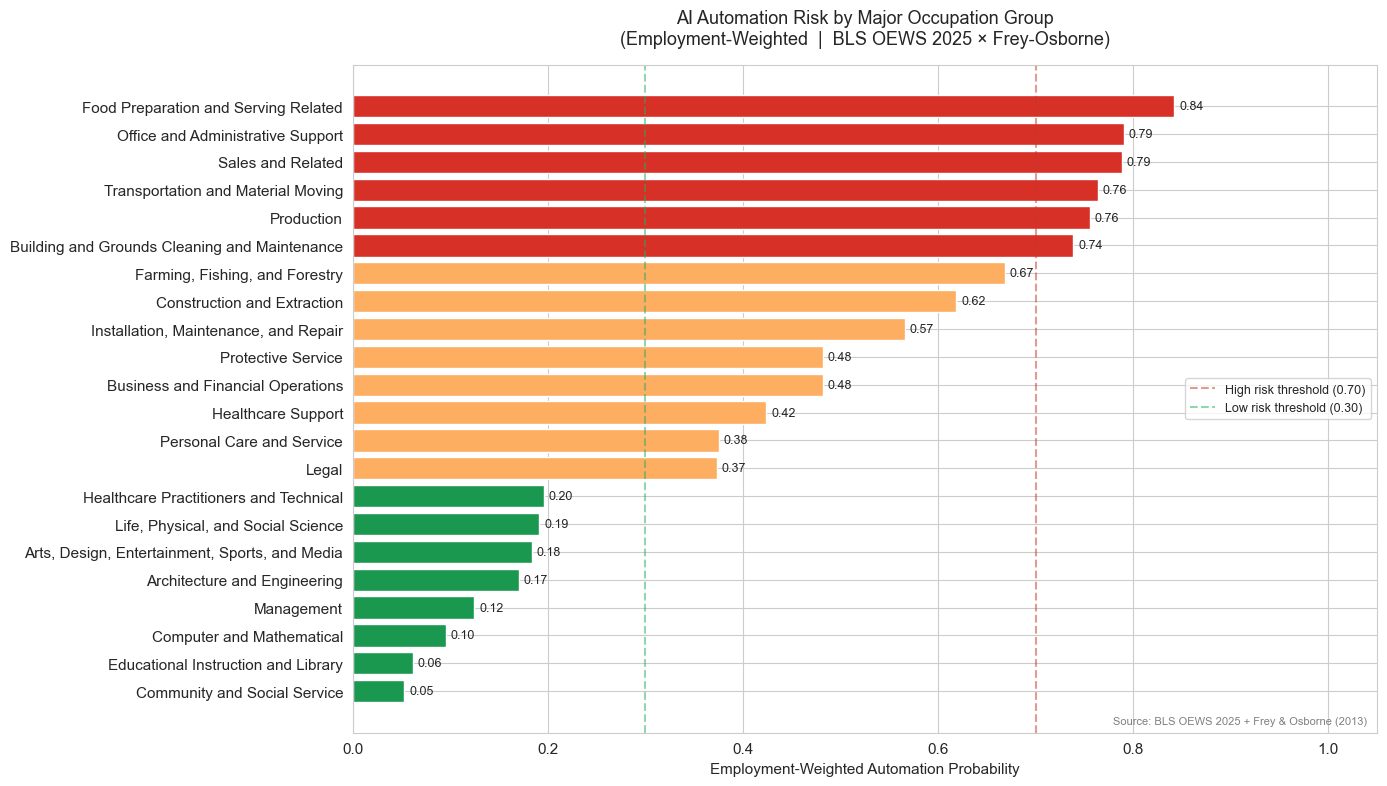

✓ Saved: 14_major_group_weighted_risk.png


In [36]:
# ── Cell 4.5: Chart — Weighted Risk by Major Group ───────────────────────────
def risk_color(r):
    if r >= 0.70:   return '#d73027'
    elif r >= 0.30: return '#fdae61'
    else:           return '#1a9850'

bar_colors = [risk_color(r) for r in df_group_risk['weighted_risk']]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(df_group_risk['short_title'], df_group_risk['weighted_risk'],
               color=bar_colors)
ax.invert_yaxis()

ax.axvline(0.70, color='#c0392b', linestyle='--', linewidth=1.5, alpha=0.5, label='High risk threshold (0.70)')
ax.axvline(0.30, color='#27ae60', linestyle='--', linewidth=1.5, alpha=0.5, label='Low risk threshold (0.30)')

for bar, val in zip(bars, df_group_risk['weighted_risk']):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va='center', fontsize=9)

ax.set_xlim(0, 1.05)
ax.set_xlabel("Employment-Weighted Automation Probability")
ax.set_title("AI Automation Risk by Major Occupation Group\n(Employment-Weighted  |  BLS OEWS 2025 × Frey-Osborne)", pad=15)
ax.legend(fontsize=9)
ax.text(0.99, 0.01, "Source: BLS OEWS 2025 + Frey & Osborne (2013)",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/14_major_group_weighted_risk.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 14_major_group_weighted_risk.png")

In [37]:
# ── Cell 4.6: Top Metros by High-Risk Employment ──────────────────────────────
query_metro_risk = f"""
    SELECT
        b.area_title,
        b.occ_code,
        b.tot_emp
    FROM bls_oews b
    JOIN automation_scores a
        ON LEFT(b.occ_code, 7) = LEFT(a.occ_code, 7)
    WHERE b.year      = 2025
      AND b.data_type = 'msa'
      AND {DETAILED_FILTER.replace('occ_code', 'b.occ_code')}
      AND b.tot_emp IS NOT NULL
      AND a.automation_prob > 0.70
"""
df_metro_raw = pd.read_sql(query_metro_risk, engine)
df_metro_raw['tot_emp'] = pd.to_numeric(df_metro_raw['tot_emp'], errors='coerce')
df_metro_raw = df_metro_raw.dropna(subset=['tot_emp'])

df_metro_risk = (
    df_metro_raw
    .groupby('area_title')
    .agg(
        high_risk_emp       = ('tot_emp',   'sum'),
        high_risk_occ_count = ('occ_code',  'nunique')
    )
    .reset_index()
    .nlargest(10, 'high_risk_emp')
    .reset_index(drop=True)
)
df_metro_risk['short_area'] = (
    df_metro_risk['area_title']
    .str.split(',').str[0]
    .str.split('-').str[0]
    .str.strip()
)
print(df_metro_risk[['short_area', 'high_risk_emp', 'high_risk_occ_count']].to_string(index=False))

  short_area  high_risk_emp  high_risk_occ_count
    New York      2968970.0                  248
 Los Angeles      2152630.0                  241
     Chicago      1600110.0                  219
      Dallas      1360730.0                  226
     Houston      1130300.0                  220
       Miami      1086740.0                  205
     Atlanta      1014570.0                  209
Philadelphia       935750.0                  231
  Washington       885520.0                  209
     Phoenix       867640.0                  191


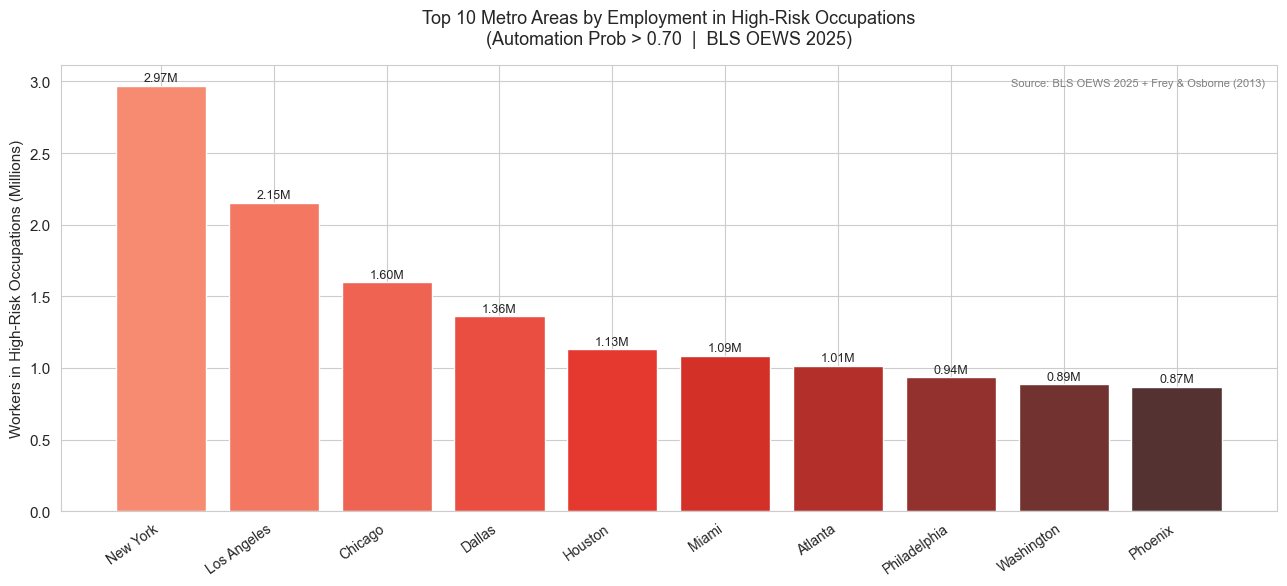

✓ Saved: 15_top_metro_high_risk_employment.png


In [38]:
# ── Cell 4.7: Chart — Top 10 Metros by High-Risk Employment ──────────────────
fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(df_metro_risk['short_area'],
              df_metro_risk['high_risk_emp'] / 1e6,
              color=sns.color_palette("Reds_d", 10))

for bar, val in zip(bars, df_metro_risk['high_risk_emp']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val/1e6:.2f}M", ha='center', va='bottom', fontsize=9)

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=10)
ax.set_ylabel("Workers in High-Risk Occupations (Millions)")
ax.set_title("Top 10 Metro Areas by Employment in High-Risk Occupations\n(Automation Prob > 0.70  |  BLS OEWS 2025)", pad=15)
ax.text(0.99, 0.97, "Source: BLS OEWS 2025 + Frey & Osborne (2013)",
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/15_top_metro_high_risk_employment.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: 15_top_metro_high_risk_employment.png")

## Section 5 — Key EDA Findings

### Finding 1: Employment is Concentrated in High-Risk Groups
Office/Admin, Sales, and Food Prep collectively employ tens of millions of workers and sit
in the medium-to-high automation risk tier. The scale of exposure makes this a meaningful
societal issue, not a niche one.

### Finding 2: Automation Risk is Bimodal
Scores cluster near 0 (creative/social roles) and near 1 (routine cognitive/physical roles).
The sparse middle suggests automation pathways are structurally clear or unclear —
not ambiguous by degree.

### Finding 3: Education is the Strongest Single Predictor
Near-monotonic relationship between education level and risk. Less-than-high-school roles
median near 0.85; doctoral roles near 0.05. Education will be an important control variable
in Part 5.

### Finding 4: ~40–47% of Covered Workers Are in High-Risk Occupations
Employment-weighted calculation confirms Frey & Osborne's original estimate holds
approximately at 2025 employment levels.

### Finding 5: O*NET Activities Validate the Theoretical Framework
High-risk occupations score measurably higher on information processing and computer
interaction, and lower on caregiving/physical activities. O*NET adds a genuinely independent
dimension — not redundant with Frey-Osborne.

### Finding 6: Join Coverage is ~80–85%
~15–20% of BLS occupations lack a Frey-Osborne score (newer SOC codes post-2013).
**Part 5 strategy:** impute missing scores using median automation probability of the
same 2-digit major occupation group.

### Finding 7: Metro Risk Requires Normalization
Top metros by raw high-risk employment are simply the largest cities.
Part 5 must divide high-risk employment by total metro employment to produce a
displacement *rate* rather than a population proxy.

---

### Feature Engineering Roadmap for Part 5
1. `yoy_emp_change` — employment trend 2018–2025, with 2020 flagged
2. `ai_exposure_score` — O*NET IM-scale weighted avg of top 4 high-exposure activities
3. `wage_stagnation_flag` — wage growth below CPI inflation threshold
4. `coverage_flag` — 1 if Frey-Osborne score exists, 0 if imputed
5. `norm_high_risk_rate` — metro level: high-risk employment / total employment